In [2]:
# Cell 1: Imports and Setup
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from wordcloud import WordCloud
import warnings

# Add project root to path
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

from src.data.database import Conversation, Message, Summary
from src.utils.config_loader import get_config

# Styling
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful!")

✅ All imports successful!


In [4]:
# Cell 2: Load data from database
import os

# Direct path to database
db_path = os.path.join('..', 'data', 'chat_conversations.db')
print(f"📍 Database path: {db_path}")

# Create engine
engine = create_engine(f'sqlite:///{db_path}')

# Load conversations
conversations_df = pd.read_sql_table('conversations', engine)
print(f"\n📊 Loaded {len(conversations_df)} conversations")
print(conversations_df.head())

print("\n" + "="*60 + "\n")

# Load messages
messages_df = pd.read_sql_table('messages', engine)
print(f"💬 Loaded {len(messages_df)} messages")
print(messages_df.head())

📍 Database path: ../data/chat_conversations.db

📊 Loaded 14731 conversations
   conversation_id                 created_at    channel     status
0                1 2025-10-29 14:31:53.907524  messenger  completed
1                2 2025-10-29 14:31:53.909955  messenger  completed
2                3 2025-10-29 14:31:53.915367  messenger  completed
3                4 2025-10-29 14:31:53.919249  messenger  completed
4                5 2025-10-29 14:31:53.925480  messenger  completed


💬 Loaded 164505 messages
   message_id  conversation_id  sender  \
0           1                1  Amanda   
1           2                1   Jerry   
2           3                1  Amanda   
3           4                2  Olivia   
4           5                2  Oliver   

                               message_text                  timestamp  
0        i baked cookies. do you want some? 2025-10-29 14:31:53.909792  
1                                     sure! 2025-10-29 14:31:53.909841  
2               

In [ ]:
# Cell 3: Basic Statistics

print("📈 DATASET OVERVIEW")
print("="*60)
print(f"Total Conversations: {len(conversations_df):,}")
print(f"Total Messages: {len(messages_df):,}")
print(f"Average Messages per Conversation: {len(messages_df)/len(conversations_df):.2f}")

📈 DATASET OVERVIEW
Total Conversations: 14,731
Total Messages: 164,505
Average Messages per Conversation: 11.17


In [7]:
# Cell 3: Check what columns we have

print("📋 CONVERSATIONS COLUMNS:")
print(conversations_df.columns.tolist())
print("\n📋 MESSAGES COLUMNS:")
print(messages_df.columns.tolist())

print("\n" + "="*60)
print("Sample message data:")
print(messages_df.head(3))

📋 CONVERSATIONS COLUMNS:
['conversation_id', 'created_at', 'channel', 'status']

📋 MESSAGES COLUMNS:
['message_id', 'conversation_id', 'sender', 'message_text', 'timestamp']

Sample message data:
   message_id  conversation_id  sender                        message_text  \
0           1                1  Amanda  i baked cookies. do you want some?   
1           2                1   Jerry                               sure!   
2           3                1  Amanda         i'll bring you tomorrow :-)   

                   timestamp  
0 2025-10-29 14:31:53.909792  
1 2025-10-29 14:31:53.909841  
2 2025-10-29 14:31:53.909863  


In [9]:
conversations_df.head()

,conversation_id,created_at,channel,status
0,1,2025-10-29 14:31:53.907524,messenger,completed
1,2,2025-10-29 14:31:53.909955,messenger,completed
2,3,2025-10-29 14:31:53.915367,messenger,completed
3,4,2025-10-29 14:31:53.919249,messenger,completed
4,5,2025-10-29 14:31:53.925480,messenger,completed


In [10]:
messages_df.head()

,message_id,conversation_id,sender,message_text,timestamp,word_count,char_count
0,1,1,Amanda,i baked cookies. do you want some?,2025-10-29 14:31:53.909792,7,34
1,2,1,Jerry,sure!,2025-10-29 14:31:53.909841,1,5
2,3,1,Amanda,i'll bring you tomorrow :-),2025-10-29 14:31:53.909863,5,27
3,4,2,Olivia,who are you voting for in this election?,2025-10-29 14:31:53.915179,8,40
4,5,2,Oliver,liberals as always.,2025-10-29 14:31:53.915228,3,19


In [13]:
# Cell 3: Basic Statistics

print("📈 DATASET OVERVIEW")
print("="*60)
print(f"Total Conversations: {len(conversations_df):,}")
print(f"Total Messages: {len(messages_df):,}")
print(f"Average Messages per Conversation: {len(messages_df)/len(conversations_df):.2f}")

print("\n📊 MESSAGE STATISTICS")
print("="*60)

# Add word count to messages
messages_df['word_count'] = messages_df['message_text'].str.split().str.len()
messages_df['char_count'] = messages_df['message_text'].str.len()

print(f"Average Words per Message: {messages_df['word_count'].mean():.2f}")
print(f"Median Words per Message: {messages_df['word_count'].median():.2f}")
print(f"Max Words in a Message: {messages_df['word_count'].max()}")
print(f"Min Words in a Message: {messages_df['word_count'].min()}")

print("\n💬 MESSAGES PER CONVERSATION")
print("="*60)

# Count messages per conversation
messages_per_conv = messages_df.groupby('conversation_id').size()
print(f"Average: {messages_per_conv.mean():.2f} messages")
print(f"Median: {messages_per_conv.median():.0f} messages")
print(f"Max: {messages_per_conv.max()} messages")
print(f"Min: {messages_per_conv.min()} messages")

print("\n✅ Basic statistics calculated!")

📈 DATASET OVERVIEW
Total Conversations: 14,731
Total Messages: 164,505
Average Messages per Conversation: 11.17

📊 MESSAGE STATISTICS
Average Words per Message: 7.39
Median Words per Message: 6.00
Max Words in a Message: 119
Min Words in a Message: 0

💬 MESSAGES PER CONVERSATION
Average: 11.17 messages
Median: 10 messages
Max: 46 messages
Min: 3 messages

✅ Basic statistics calculated!


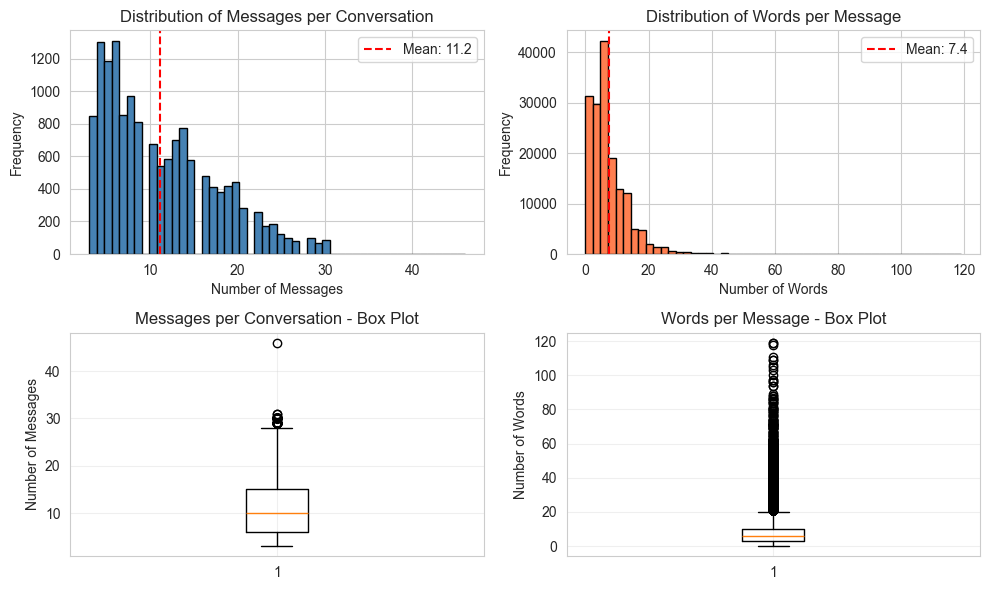

✅ Visualizations created!


In [16]:
# Cell 4: Distribution Visualizations

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# 1. Messages per conversation distribution
axes[0, 0].hist(messages_per_conv, bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Number of Messages')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Messages per Conversation')
axes[0, 0].axvline(messages_per_conv.mean(), color='red', linestyle='--', label=f'Mean: {messages_per_conv.mean():.1f}')
axes[0, 0].legend()

# 2. Words per message distribution
axes[0, 1].hist(messages_df['word_count'], bins=50, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Number of Words')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Words per Message')
axes[0, 1].axvline(messages_df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {messages_df["word_count"].mean():.1f}')
axes[0, 1].legend()

# 3. Box plot - messages per conversation
axes[1, 0].boxplot(messages_per_conv, vert=True)
axes[1, 0].set_ylabel('Number of Messages')
axes[1, 0].set_title('Messages per Conversation - Box Plot')
axes[1, 0].grid(True, alpha=0.3)

# 4. Box plot - words per message
axes[1, 1].boxplot(messages_df['word_count'].dropna(), vert=True)
axes[1, 1].set_ylabel('Number of Words')
axes[1, 1].set_title('Words per Message - Box Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations created!")

# Observations:
1. Distribution of messages per convo and words per msg are right skewed - and not normally distributed. 
2. words per message has a lot of outliers! 
3. More conversations are short

📝 TOTAL WORDS PER CONVERSATION
Average: 82.58 words
Median: 63.00 words
Max: 781 words
Min: 4 words


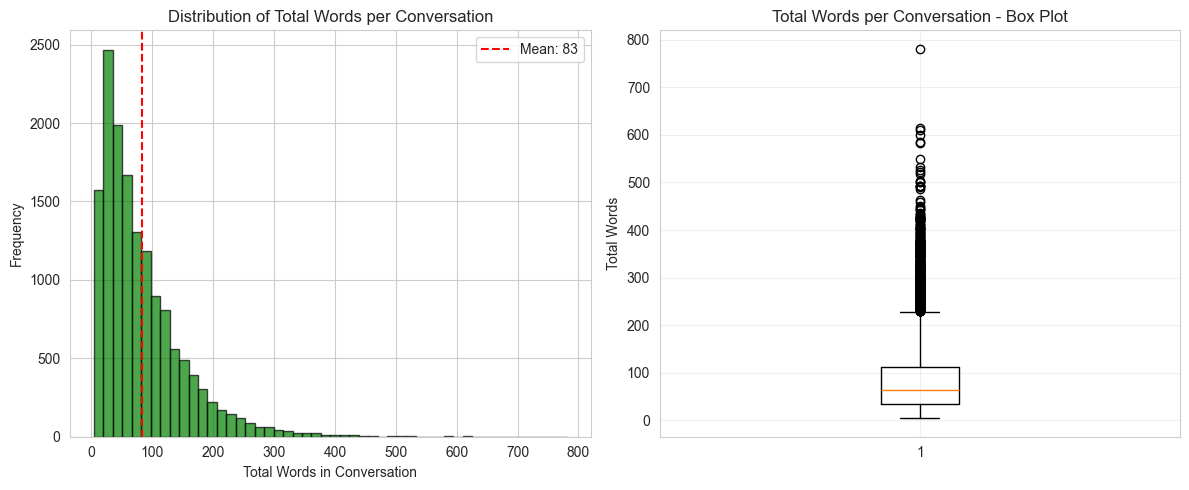


✅ Conversation length analysis complete!


In [17]:
# Cell 5: Total words per conversation

# Calculate total words per conversation
words_per_conv = messages_df.groupby('conversation_id')['word_count'].sum()

print("📝 TOTAL WORDS PER CONVERSATION")
print("="*60)
print(f"Average: {words_per_conv.mean():.2f} words")
print(f"Median: {words_per_conv.median():.2f} words")
print(f"Max: {words_per_conv.max()} words")
print(f"Min: {words_per_conv.min()} words")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(words_per_conv, bins=50, color='green', edgecolor='black', alpha=0.7)
plt.xlabel('Total Words in Conversation')
plt.ylabel('Frequency')
plt.title('Distribution of Total Words per Conversation')
plt.axvline(words_per_conv.mean(), color='red', linestyle='--', label=f'Mean: {words_per_conv.mean():.0f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(words_per_conv, vert=True)
plt.ylabel('Total Words')
plt.title('Total Words per Conversation - Box Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Conversation length analysis complete!")

In [18]:
# Cell 6: Analyze summaries

# Load summaries from database
summaries_df = pd.read_sql_table('summaries', engine)
print(f"📝 Loaded {len(summaries_df)} summaries")
print(summaries_df.head())

# Check if we have original summaries in conversations table
print("\n🔍 Checking conversations table for summaries...")
print(conversations_df.columns.tolist())

📝 Loaded 14731 summaries
   summary_id  conversation_id  \
0           1                1   
1           2                2   
2           3                3   
3           4                4   
4           5                5   

                                        summary_text    model_version  \
0  Amanda baked cookies and will bring Jerry some...  human_annotated   
1  Olivia and Olivier are voting for liberals in ...  human_annotated   
2  Kim may try the pomodoro technique recommended...  human_annotated   
3  Edward thinks he is in love with Bella. Rachel...  human_annotated   
4  Sam is confused, because he overheard Rick com...  human_annotated   

                  created_at  
0 2025-10-29 14:31:53.909880  
1 2025-10-29 14:31:53.915284  
2 2025-10-29 14:31:53.919163  
3 2025-10-29 14:31:53.925210  
4 2025-10-29 14:31:53.929300  

🔍 Checking conversations table for summaries...
['conversation_id', 'created_at', 'channel', 'status']


📝 SUMMARY STATISTICS
Total Summaries: 14,731
Average Words per Summary: 20.32
Median Words per Summary: 18.00
Max Words in Summary: 64
Min Words in Summary: 1

🔄 COMPRESSION RATIO
Average Compression: 4.21x
Median Compression: 3.35x
(e.g., 5x means: 100 words → 20 word summary)


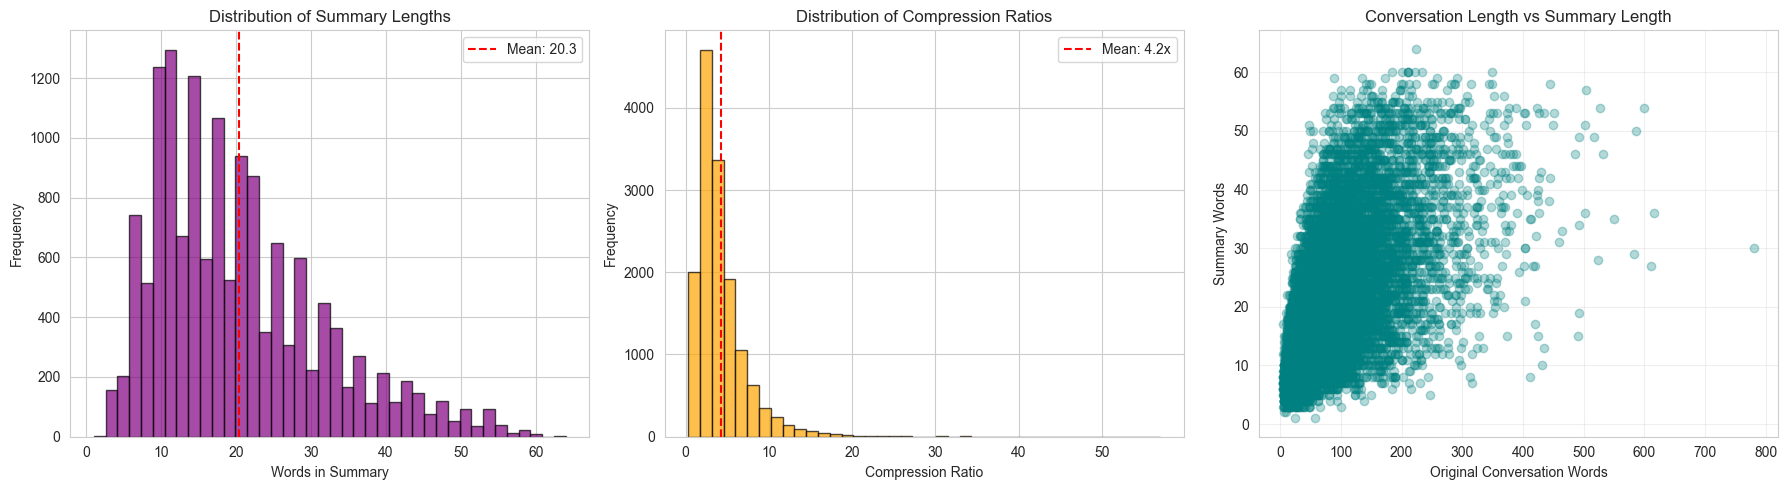


✅ Summary analysis complete!


In [19]:
# Cell 7: Analyze summaries

# Add word count to summaries
summaries_df['summary_word_count'] = summaries_df['summary_text'].str.split().str.len()

print("📝 SUMMARY STATISTICS")
print("="*60)
print(f"Total Summaries: {len(summaries_df):,}")
print(f"Average Words per Summary: {summaries_df['summary_word_count'].mean():.2f}")
print(f"Median Words per Summary: {summaries_df['summary_word_count'].median():.2f}")
print(f"Max Words in Summary: {summaries_df['summary_word_count'].max()}")
print(f"Min Words in Summary: {summaries_df['summary_word_count'].min()}")

# Merge with conversation word counts for compression ratio
summary_analysis = summaries_df.merge(
    words_per_conv.reset_index().rename(columns={'word_count': 'total_conv_words'}),
    left_on='conversation_id',
    right_on='conversation_id'
)

# Calculate compression ratio
summary_analysis['compression_ratio'] = (
    summary_analysis['total_conv_words'] / summary_analysis['summary_word_count']
)

print("\n🔄 COMPRESSION RATIO")
print("="*60)
print(f"Average Compression: {summary_analysis['compression_ratio'].mean():.2f}x")
print(f"Median Compression: {summary_analysis['compression_ratio'].median():.2f}x")
print(f"(e.g., 5x means: 100 words → 20 word summary)")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Summary length distribution
axes[0].hist(summaries_df['summary_word_count'], bins=40, color='purple', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Words in Summary')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Summary Lengths')
axes[0].axvline(summaries_df['summary_word_count'].mean(), color='red', linestyle='--', 
                label=f'Mean: {summaries_df["summary_word_count"].mean():.1f}')
axes[0].legend()

# Compression ratio distribution
axes[1].hist(summary_analysis['compression_ratio'], bins=40, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Compression Ratio')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Compression Ratios')
axes[1].axvline(summary_analysis['compression_ratio'].mean(), color='red', linestyle='--', 
                label=f'Mean: {summary_analysis["compression_ratio"].mean():.1f}x')
axes[1].legend()

# Scatter: Conversation length vs Summary length
axes[2].scatter(summary_analysis['total_conv_words'], 
                summary_analysis['summary_word_count'], 
                alpha=0.3, color='teal')
axes[2].set_xlabel('Original Conversation Words')
axes[2].set_ylabel('Summary Words')
axes[2].set_title('Conversation Length vs Summary Length')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Summary analysis complete!")

🔤 MOST COMMON WORDS
Top 20 most frequent words:

i               : 43,983
you             : 34,913
the             : 31,490
to              : 28,808
a               : 22,180
and             : 17,503
it              : 16,018
for             : 11,805
in              : 11,153
is              : 10,852
of              : 10,677
have            : 10,650
but             : 10,069
so              : 9,390
that            : 9,309
be              : 8,989
we              : 8,589
are             : 8,272
me              : 8,173
my              : 8,094


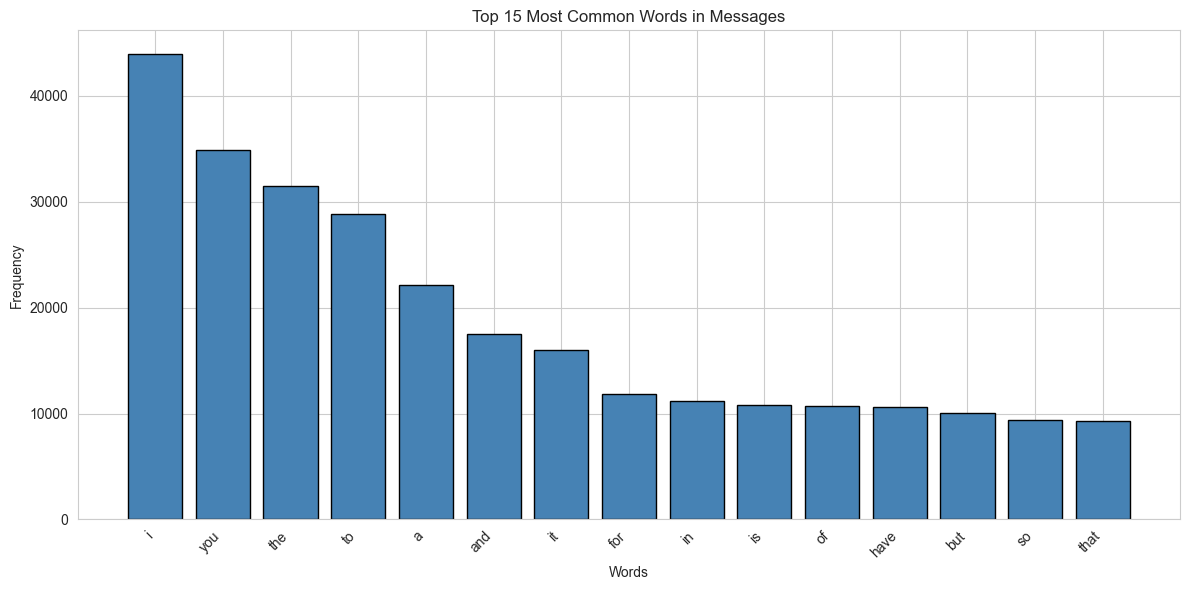


✅ Word frequency analysis complete!


In [20]:
# Cell 8: Most common words analysis

from collections import Counter

# Get all message text
all_text = ' '.join(messages_df['message_text'].astype(str).tolist()).lower()

# Split into words and count
words = all_text.split()
word_counts = Counter(words)

print("🔤 MOST COMMON WORDS")
print("="*60)
print("Top 20 most frequent words:\n")
for word, count in word_counts.most_common(20):
    print(f"{word:15} : {count:,}")

# Visualize top 15
top_words = dict(word_counts.most_common(15))

plt.figure(figsize=(12, 6))
plt.bar(top_words.keys(), top_words.values(), color='steelblue', edgecolor='black')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 15 Most Common Words in Messages')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✅ Word frequency analysis complete!")

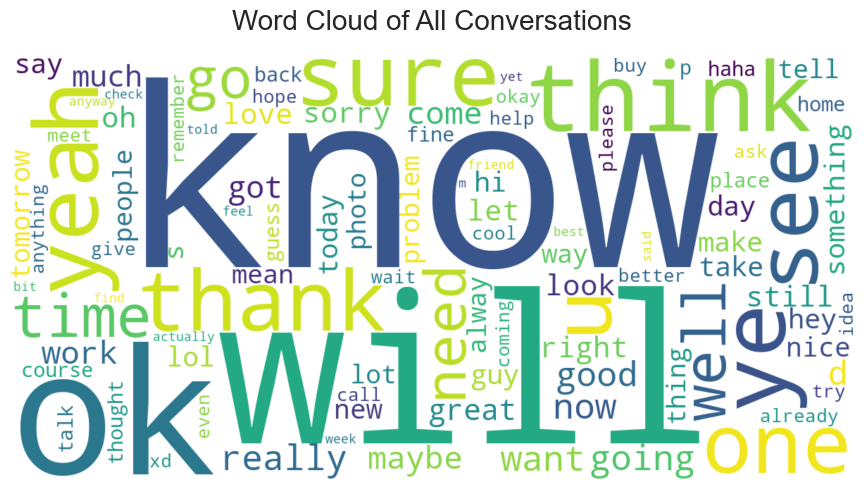

✅ Word cloud generated!


In [24]:
# Cell 9: Word Cloud

from wordcloud import WordCloud, STOPWORDS

# Combine all message text
all_messages_text = ' '.join(messages_df['message_text'].astype(str).tolist())

# Generate word cloud
wordcloud = WordCloud(
    width=1200, 
    height=600,
    background_color='white',
    colormap='viridis',
    stopwords=STOPWORDS,
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(all_messages_text)

# Display
plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Conversations', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

print("✅ Word cloud generated!")


In [26]:
# Cell 10: EDA Summary - Key Findings

print("="*70)
print("📊 EXPLORATORY DATA ANALYSIS - KEY FINDINGS")
print("="*70)

print("\n🗂️ DATASET OVERVIEW")
print("-" * 70)
print(f"  • Total Conversations: {len(conversations_df):,}")
print(f"  • Total Messages: {len(messages_df):,}")
print(f"  • Total Summaries: {len(summaries_df):,}")

print("\n💬 CONVERSATION CHARACTERISTICS")
print("-" * 70)
print(f"  • Average Messages per Conversation: {messages_per_conv.mean():.1f}")
print(f"  • Average Words per Conversation: {words_per_conv.mean():.1f}")
print(f"  • Longest Conversation: {words_per_conv.max()} words ({messages_per_conv.max()} messages)")
print(f"  • Shortest Conversation: {words_per_conv.min()} words ({messages_per_conv.min()} messages)")

print("\n📝 MESSAGE PATTERNS")
print("-" * 70)
print(f"  • Average Words per Message: {messages_df['word_count'].mean():.1f}")
print(f"  • Most messages are short (median: {messages_df['word_count'].median():.0f} words)")
print(f"  • Distribution: Right-skewed (more short messages)")

print("\n✨ SUMMARY CHARACTERISTICS")
print("-" * 70)
print(f"  • Average Summary Length: {summaries_df['summary_word_count'].mean():.1f} words")
print(f"  • Average Compression Ratio: {summary_analysis['compression_ratio'].mean():.2f}x")
print(f"  • Example: {words_per_conv.mean():.0f} words → {summaries_df['summary_word_count'].mean():.0f} words")

print("\n🎯 KEY INSIGHTS FOR MODEL TRAINING")
print("-" * 70)
print("  ✓ Data fits well within transformer token limits (512 tokens)")
print("  ✓ Conversations are manageable length (avg 83 words)")
print("  ✓ Target summary length: ~20 words")
print("  ✓ Need to handle both short (3 msgs) and long (46 msgs) conversations")
print("  ✓ Right-skewed distribution is realistic and expected")

print("\n🚀 NEXT STEPS")
print("-" * 70)
print("  1. Prepare training dataset (train/val/test splits)")
print("  2. Fine-tune BART/T5 model on this data")
print("  3. Evaluate with ROUGE/BLEU metrics")
print("  4. Target: ROUGE-L > 0.40 (competitive baseline)")

print("\n" + "="*70)
print("✅ EDA Complete! Ready to move to Model Training phase.")
print("="*70)

📊 EXPLORATORY DATA ANALYSIS - KEY FINDINGS

🗂️ DATASET OVERVIEW
----------------------------------------------------------------------
  • Total Conversations: 14,731
  • Total Messages: 164,505
  • Total Summaries: 14,731

💬 CONVERSATION CHARACTERISTICS
----------------------------------------------------------------------
  • Average Messages per Conversation: 11.2
  • Average Words per Conversation: 82.6
  • Longest Conversation: 781 words (46 messages)
  • Shortest Conversation: 4 words (3 messages)

📝 MESSAGE PATTERNS
----------------------------------------------------------------------
  • Average Words per Message: 7.4
  • Most messages are short (median: 6 words)
  • Distribution: Right-skewed (more short messages)

✨ SUMMARY CHARACTERISTICS
----------------------------------------------------------------------
  • Average Summary Length: 20.3 words
  • Average Compression Ratio: 4.21x
  • Example: 83 words → 20 words

🎯 KEY INSIGHTS FOR MODEL TRAINING
------------------------